# **Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) is an unsupervised dimensionality-reduction technique used to identify the main axes of variation in a dataset. It transforms a set of potentially correlated variables into a smaller number of new, uncorrelated variables called principal components, while preserving as much of the original variance as possible.

In this analysis, PCA is used to explore and visualize qualitative differences between language models based on multiple evaluation metrics.

Data used for PCA

The PCA was performed using three numerical qualitative metrics:
*	Socraticity (0–5)
*	Conceptual quality (0–5)
*	Hallucination (0–5)

Since higher hallucination scores indicate worse performance, the hallucination metric was inverted prior to analysis so that higher values consistently represent better behavior across all dimensions. This alignment improves the interpretability of the resulting components.

Only these qualitative metrics were used to compute the PCA. Categorical variables such as model, architecture, and temperature were excluded from the PCA computation and used solely for visualization and interpretation.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Leer excel file
data = pd.read_excel("data/Datos_spider_qwen25_combined_550.xlsx")

# Reemplazar "NaN" con 0.0
data_cleaned = data.replace(np.nan, 0.0)
data_cleaned["Unnamed: 0"] = data_cleaned["Unnamed: 0"].replace("qwen2.5:latest", "Qwen2.5")
# Cambiar nombre de columna
data_cleaned.rename(columns={"Unnamed: 0": "Model"}, inplace=True)
data_cleaned.rename(columns={"Modelo": "Arch"}, inplace=True)

# Convertir Temp a string
data_cleaned["Temp"] = data_cleaned["Temp"].astype(str)

# Invertir alucinaciones (mas bajas son mejores)
data_cleaned["Hallutination_inv (1-5)"] = 5-data_cleaned["Hallutination (1-5)"]

# Describir datos numéricos
numerical_data = data_cleaned.select_dtypes(include=[np.number])

print(numerical_data.describe())
print(data_cleaned["Model"].value_counts())
print(data_cleaned["Arch"].value_counts())

       Socraticity (1-5)  Conceptual (1-5)  Hallutination (1-5)  \
count        2201.000000       2201.000000          2201.000000   
mean            3.353786          2.342230             2.131908   
std             1.413728          1.907196             1.170694   
min             0.000000          0.000000             0.000000   
25%             3.000000          0.000000             1.000000   
50%             4.000000          3.000000             2.000000   
75%             4.000000          4.000000             3.000000   
max             5.000000          5.000000             5.000000   

       Hallutination_inv (1-5)  
count              2201.000000  
mean                  2.868092  
std                   1.170694  
min                   0.000000  
25%                   2.000000  
50%                   3.000000  
75%                   4.000000  
max                   5.000000  
Model
Qwen2.5    2201
Name: count, dtype: int64
Arch
rag          551
base         550
finetuned   

## **Preprocessing**

Before applying PCA, all features were standardized using z-score normalization:
*	Each variable was centered to zero mean
*	Each variable was scaled to unit variance

Standardization is required because PCA is sensitive to the relative scale of the input variables.

In [ ]:
# Preprocessing

features = [data_cleaned.columns[3], data_cleaned.columns[4], data_cleaned.columns[-1]]

numerical_data = data_cleaned[features]
scaler = StandardScaler()
numerical_data_scaled = scaler.fit_transform(numerical_data)

## **Computation of PC1 and PC2**

PCA was computed using singular value decomposition on the standardized data. The resulting principal components are:
* **PC1 (Principal Component 1):**
The direction in feature space that captures the maximum variance in the data.
* **PC2 (Principal Component 2):**
The direction orthogonal to PC1 that captures the second-largest amount of variance.

Each observation is projected onto these new axes, producing coordinates in the PCA space. These coordinates are what define the PC1 and PC2 values shown in the plots.

In this analysis:
* **PC1** explains **~68%** of the total variance
* **PC2** explains **~28%** of the total variance
* Together, **PC1** and **PC2** capture **~96%** of the overall variability, meaning that the two-dimensional PCA representation provides an excellent summary of the original three-dimensional metric space.

Explained variance ratio: [0.57391407 0.31140969]
Total explained variance: 0.8853237635179443


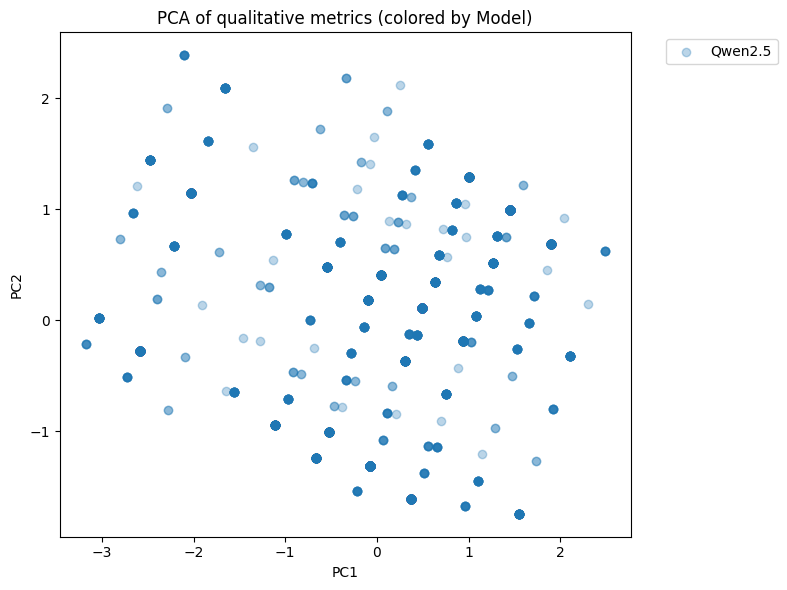

Model
Qwen2.5    2201
Name: count, dtype: int64


In [ ]:
# PCA analysis by Model

pca = PCA(n_components=2)
pca_result = pca.fit_transform(numerical_data_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))

for model in data_cleaned["Model"].unique():
    mask = data_cleaned["Model"] == model
    plt.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        label=model,
        alpha=0.3
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of qualitative metrics (colored by Model)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(data_cleaned["Model"].value_counts())

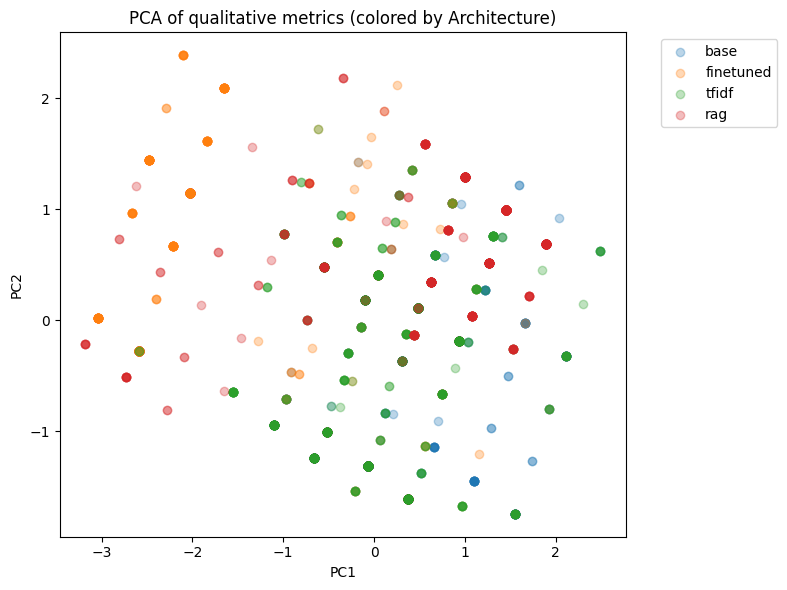

Arch
rag          551
base         550
finetuned    550
tfidf        550
Name: count, dtype: int64


In [ ]:
# PCA analysis by architecture

plt.figure(figsize=(8, 6))

for arch in data_cleaned["Arch"].unique():
    mask = data_cleaned["Arch"] == arch
    plt.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        label=arch,
        alpha=0.3
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of qualitative metrics (colored by Architecture)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(data_cleaned["Arch"].value_counts())

## **Centroid analysis in PCA space**

In addition to visualizing individual observations, centroid analysis was performed to summarize and compare the average behavior of different groups in the PCA space.

A centroid represents the mean position of a group of observations in the reduced PCA space. In this context, centroids were computed for:
*	Models
*	Architectures

Each centroid corresponds to the average coordinates along PC1 and PC2 for all observations belonging to a given group.

     Model           PC1           PC2
0  Qwen2.5  1.457767e-17 -2.012626e-17


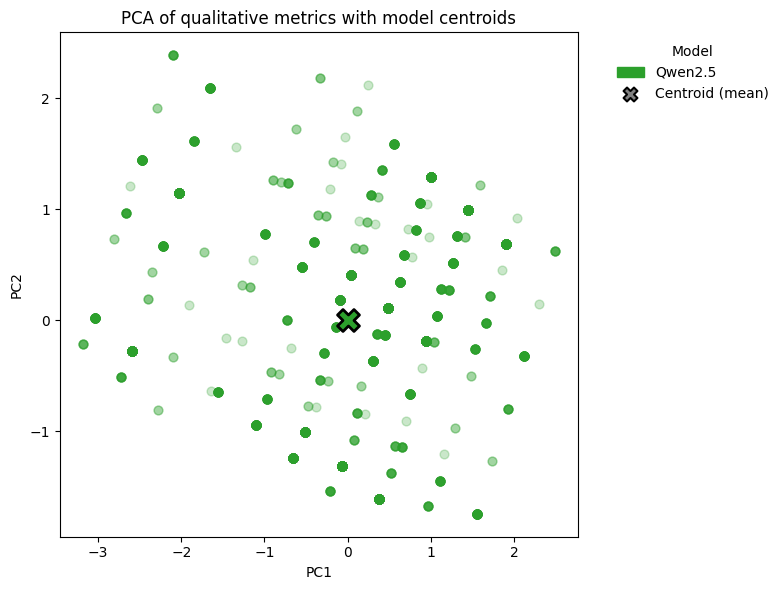

In [ ]:
pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)
pca_df["Model"] = data_cleaned["Model"].values

centroids_model = (
    pca_df
    .groupby("Model")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

print(centroids_model)

model_colors = {
    "Qwen2.5": "tab:green",
}

plt.figure(figsize=(8, 6))

# 1) puntos individuales (bajo alpha)
for model in pca_df["Model"].unique():
    mask = pca_df["Model"] == model
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        color=model_colors.get(model, "gray"),
        alpha=0.25,
        s=40
    )

# 2) centroides (puntos grandes)
for i in range(len(centroids_model)):
    row = centroids_model.iloc[i]
    plt.scatter(
        row["PC1"],
        row["PC2"],
        color=model_colors.get(row["Model"], "black"),
        s=250,
        edgecolors="black",
        linewidths=2,
        marker="X"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of qualitative metrics with model centroids")

import matplotlib.patches as mpatches
handles = []
for m, c in model_colors.items():
    if m in pca_df["Model"].unique():
        handles.append(mpatches.Patch(color=c, label=m))
handles.append(
    plt.scatter([], [], marker="X", color="gray", s=100,
                edgecolors="black", linewidths=1.5, label="Centroid (mean)")
)
plt.legend(handles=handles, title="Model", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


        Arch       PC1       PC2
0       base  0.199533 -0.591709
1  finetuned -1.311669  0.286802
2        rag  0.975690  0.750023
3      tfidf  0.134673 -0.446479


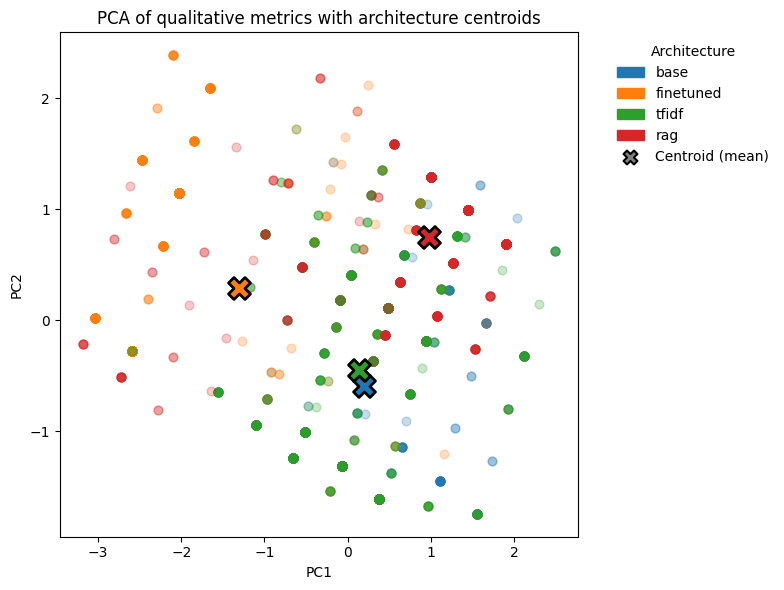

In [ ]:
pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)
pca_df["Arch"] = data_cleaned["Arch"].values

centroids_arch = (
    pca_df
    .groupby("Arch")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

print(centroids_arch)

arch_colors = {
    "base":     "tab:blue",
    "finetuned":"tab:orange",
    "tfidf":    "tab:green",
    "rag":      "tab:red",
}

plt.figure(figsize=(8, 6))

# 1) puntos individuales (bajo alpha)
for arch in pca_df["Arch"].unique():
    mask = pca_df["Arch"] == arch
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        color=arch_colors.get(arch, "gray"),
        alpha=0.25,
        s=40
    )

# 2) centroides (puntos grandes)
for i in range(len(centroids_arch)):
    row = centroids_arch.iloc[i]
    plt.scatter(
        row["PC1"],
        row["PC2"],
        color=arch_colors.get(row["Arch"], "black"),
        s=250,
        edgecolors="black",
        linewidths=2,
        marker="X"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of qualitative metrics with architecture centroids")

import matplotlib.patches as mpatches
handles = []
for a, c in arch_colors.items():
    if a in pca_df["Arch"].unique():
        handles.append(mpatches.Patch(color=c, label=a))
handles.append(
    plt.scatter([], [], marker="X", color="gray", s=100,
                edgecolors="black", linewidths=1.5, label="Centroid (mean)")
)
plt.legend(handles=handles, title="Architecture", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


           PC1       PC2    Model  Arch
0     0.115880 -0.837660  Qwen2.5  base
1    -0.070914 -1.311210  Qwen2.5  base
2     0.302673 -0.364111  Qwen2.5  base
3     1.104838 -1.446731  Qwen2.5  base
4     0.489467  0.109439  Qwen2.5  base
...        ...       ...      ...   ...
2196  1.898235  0.689944  Qwen2.5   rag
2197  1.898235  0.689944  Qwen2.5   rag
2198  1.450930  0.988776  Qwen2.5   rag
2199  1.450930  0.988776  Qwen2.5   rag
2200  0.975690  0.750023  Qwen2.5   rag

[2201 rows x 4 columns]


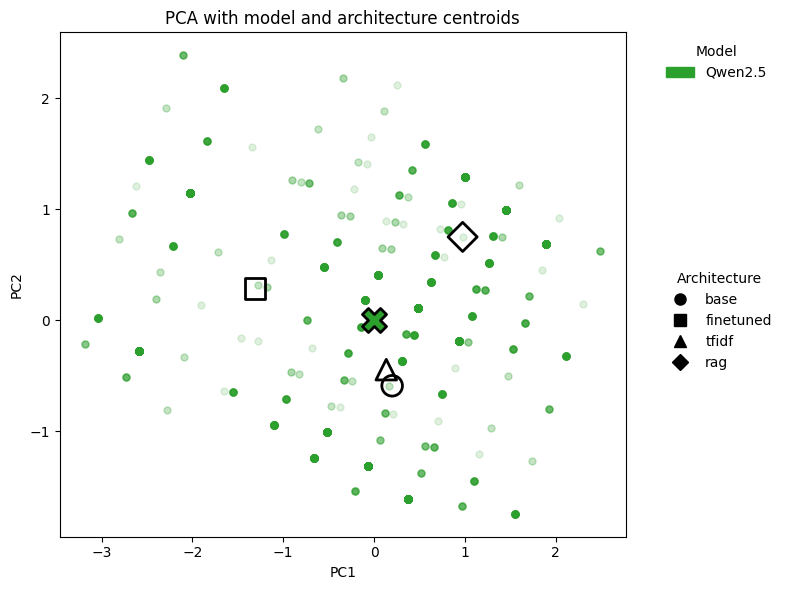

In [ ]:
# Colores por modelo
model_colors = {
    "Qwen2.5": "tab:green",
}

# Marcadores por arquitectura
arch_markers = {
    "base":     "o",
    "finetuned":"s",
    "tfidf":    "^",
    "rag":      "D",
}

plt.figure(figsize=(8, 6))

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)
pca_df["Model"] = data_cleaned["Model"].values
pca_df["Arch"] = data_cleaned["Arch"].values

print(pca_df)

# --- 1) Puntos individuales (muy suaves) ---
for model in pca_df["Model"].unique():
    mask = pca_df["Model"] == model
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        color=model_colors.get(model, "gray"),
        alpha=0.15,
        s=25
    )

# --- 2) Centroides por MODELO ---
for i in range(len(centroids_model)):
    row = centroids_model.iloc[i]
    plt.scatter(
        row["PC1"],
        row["PC2"],
        color=model_colors.get(row["Model"], "black"),
        s=300,
        marker="X",
        edgecolors="black",
        linewidths=2
    )

# --- 3) Centroides por ARQUITECTURA ---
for i in range(len(centroids_arch)):
    row = centroids_arch.iloc[i]
    plt.scatter(
        row["PC1"],
        row["PC2"],
        color="none",
        edgecolors="black",
        s=220,
        marker=arch_markers.get(row["Arch"], "o"),
        linewidths=2
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with model and architecture centroids")

import matplotlib.patches as mpatches
import matplotlib.lines as mlines
model_handles = [
    mpatches.Patch(color=c, label=m)
    for m, c in model_colors.items() if m in pca_df["Model"].unique()
]
leg1 = plt.legend(handles=model_handles, title="Model",
                   bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.gca().add_artist(leg1)
arch_handle_list = [
    mlines.Line2D([], [], color="black", marker=mk, linestyle="None",
                  markersize=8, label=a)
    for a, mk in arch_markers.items() if a in pca_df["Arch"].unique()
]
plt.legend(handles=arch_handle_list, title="Architecture",
           bbox_to_anchor=(1.05, 0.55), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()



## **Interpretation of the principal components**

Because all metrics were aligned so that higher values indicate better performance:
* **PC1** can be interpreted as an overall qualitative performance axis, combining high Socraticity, high conceptual quality, and low hallucination.
* **PC2** captures secondary variation, reflecting trade-offs and finer differences between models and configurations.

# **Bubble scatter plot**

In [ ]:
# Calcular PC1 promedio por modelo y arquitectura

df_pc1 = (
    pca_df
    .groupby(["Model", "Arch"], as_index=False)["PC1"]
    .mean()
    .rename(columns={"PC1": "Quality_PC1"})
    .replace({"base": "Base", "finetuned": "FT", "tfidf": "TF-IDF", "rag": "RAG"})
)

df2 = pd.read_excel("data/data2_qwen25.xlsx")
df2_reduced = df2[["Model", "Arch", "Latency (mean)", "Tokens (mean)"]]

df_final = pd.merge(df_pc1, df2_reduced, on=["Model", "Arch"], how="outer")
print(df_final)


     Model    Arch  Quality_PC1  Latency (mean)  Tokens (mean)
0  Qwen2.5    Base     0.199533           0.553           31.9
1  Qwen2.5      FT    -1.311669           5.854          134.9
2  Qwen2.5     RAG     0.975690           9.943           41.2
3  Qwen2.5  TF-IDF     0.134673           0.674           42.8


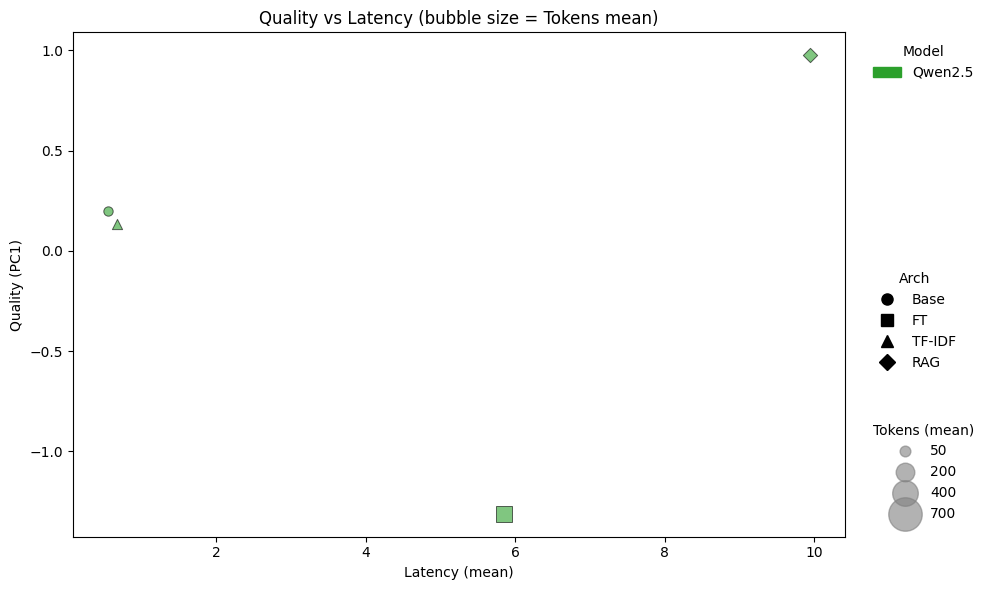

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Color per model
model_colors = {
    "Qwen2.5": "tab:green",
}

# Marker per architecture
marker_map = {
    "Base":   "o",
    "FT":     "s",
    "TF-IDF": "^",
    "RAG":    "D",
}

plt.figure(figsize=(10, 6))

for i in range(len(df_final)):
    row = df_final.iloc[i]
    color  = model_colors.get(row["Model"],  "gray")
    marker = marker_map.get(row["Arch"],     "o")
    plt.scatter(
        row["Latency (mean)"],
        row["Quality_PC1"],
        s=20 + 0.8 * row["Tokens (mean)"],
        alpha=0.6,
        color=color,
        marker=marker,
        edgecolors="black",
        linewidths=0.7
    )

plt.xlabel("Latency (mean)")
plt.ylabel("Quality (PC1)")
plt.title("Quality vs Latency (bubble size = Tokens mean)")

# --- Legend: MODELS ---
model_handles = []
for m, c in model_colors.items():
    model_handles.append(mpatches.Patch(color=c, label=m))

leg_model = plt.legend(
    handles=model_handles,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False
)
plt.gca().add_artist(leg_model)

# --- Legend: ARCHITECTURES ---
arch_handles = []
for a, mk in marker_map.items():
    arch_handles.append(
        mlines.Line2D([], [], color="black", marker=mk, linestyle="None", markersize=8, label=a)
    )

leg_arch = plt.legend(
    handles=arch_handles,
    title="Arch",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.55),
    frameon=False
)
plt.gca().add_artist(leg_arch)

# --- Legend: TOKEN SIZE ---
size_handles = []
for t in [50, 200, 400, 700]:
    size_handles.append(
        plt.scatter([], [], s=20 + 0.8 * t, color="gray", alpha=0.6, label=str(t))
    )

plt.legend(
    handles=size_handles,
    title="Tokens (mean)",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.25),
    frameon=False
)

plt.savefig(
    "quality_vs_latency_bubble.png",
    format="png",
    bbox_inches="tight",
    dpi=300
)
plt.tight_layout()
plt.show()


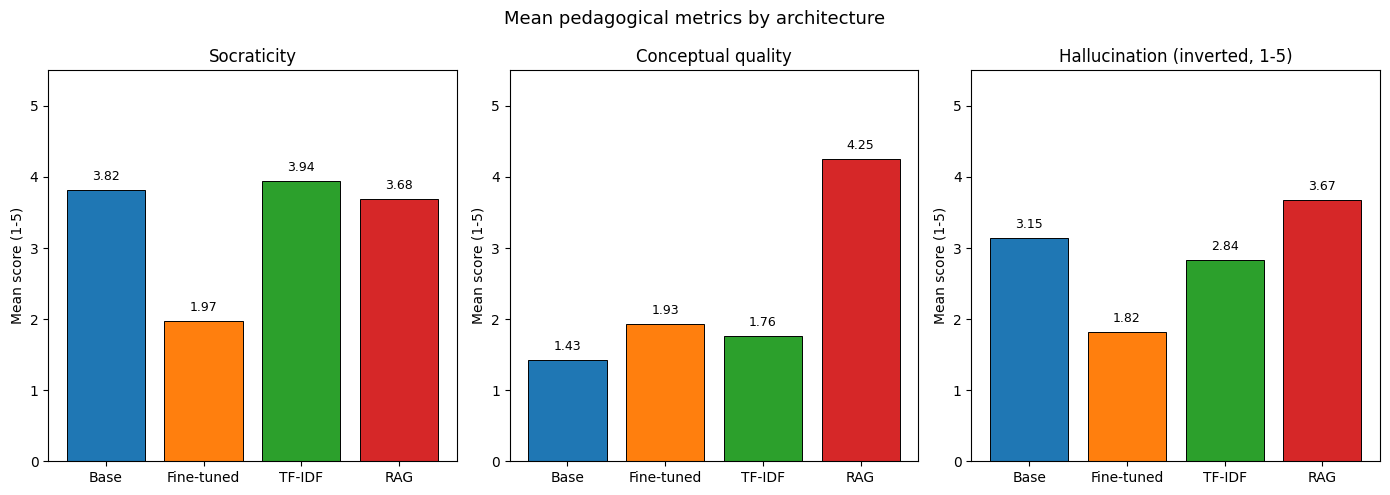

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Medias por arquitectura para cada métrica
arch_order = ["base", "finetuned", "tfidf", "rag"]
arch_labels = ["Base", "Fine-tuned", "TF-IDF", "RAG"]
arch_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

metrics = {
    "Socraticity": "Socraticity (1-5)",
    "Conceptual quality": "Conceptual (1-5)",
    "Hallucination (inverted, 1-5)": "Hallutination_inv (1-5)",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Mean pedagogical metrics by architecture", fontsize=13)

for ax, (metric_label, col) in zip(axes, metrics.items()):
    vals = [data_cleaned[data_cleaned["Arch"] == a][col].mean() for a in arch_order]
    bars = ax.bar(arch_labels, vals, color=arch_colors, edgecolor="black", linewidth=0.7)
    ax.set_title(metric_label)
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("Mean score (1-5)")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)
    # Mark TF-IDF with asterisk on Conceptual to flag methodological bias
   # if col == "Conceptual (1-5)":
    #    tfidf_idx = arch_labels.index("TF-IDF")
        #ax.text(tfidf_idx, vals[tfidf_idx] + 0.35, "*", ha="center", fontsize=14, color="red")
        #ax.text(0.5, -0.18, "* inflated by architecture (sees expected answers)",
     #           transform=ax.transAxes, ha="center", fontsize=7, color="red", style="italic")

plt.tight_layout()
plt.savefig("metrics_by_arch.png", dpi=300, bbox_inches="tight")
plt.show()


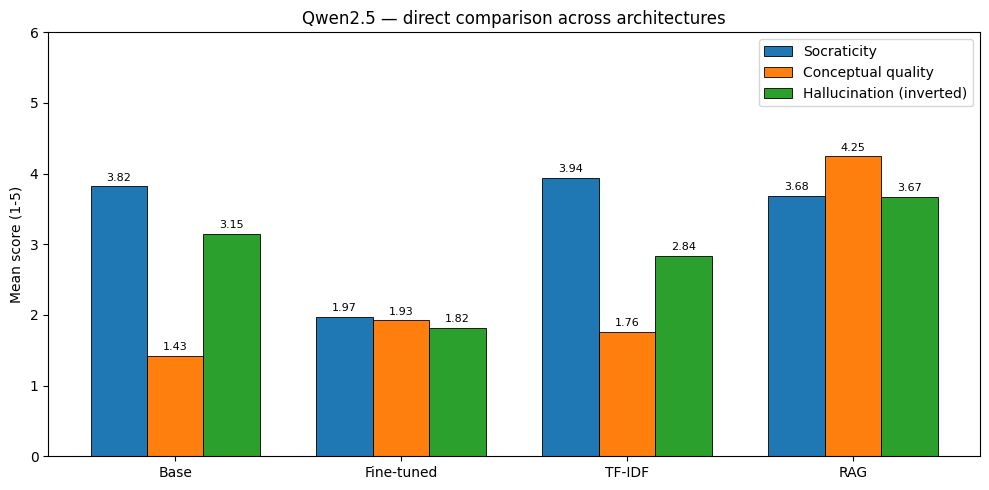

In [ ]:
# Comparación directa: Qwen2.5 en las 4 arquitecturas (mismo modelo base)
qwen = data_cleaned[data_cleaned["Model"] == "Qwen2.5"].copy()

arch_order_q = ["base", "finetuned", "tfidf", "rag"]
arch_labels_q = ["Base", "Fine-tuned", "TF-IDF", "RAG"]
arch_colors_q = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

metrics_q = [
    ("Socraticity (1-5)",       "Socraticity"),
    ("Conceptual (1-5)",         "Conceptual quality"),
    ("Hallutination_inv (1-5)",  "Hallucination (inverted)"),
]

x = np.arange(len(arch_labels_q))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for i, (col, label) in enumerate(metrics_q):
    vals = [qwen[qwen["Arch"] == a][col].mean() for a in arch_order_q]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=label, edgecolor="black", linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(arch_labels_q)
ax.set_ylim(0, 6)
ax.set_ylabel("Mean score (1-5)")
ax.set_title("Qwen2.5 — direct comparison across architectures")
ax.legend()
#ax.axvline(1.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
#ax.text(1.5, 5.7, "RAG >", ha="right", fontsize=8, color="gray")
#ax.text(1.55, 5.7, "base & FT", ha="left", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("qwen25_direct_arch_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
